# **Laboratorio N1 – Análisis Exploratorio**

¿Qué es el análisis exploratorio de datos?

El análisis exploratorio de datos (EDA, Exploratory Data Analysis) es entender los datos resumiendo sus principales características, generalmente utilizando algún tipo de representación gráfica. Este es un paso muy importante para llegar a la modelización de los datos que luego se puede utilizar para aplicar Machine learning para algún tipo de análisis predictivo. Explorar los datos no es tarea sencilla, suele llevar una cantidad de tiempo considerable. A través del análisis exploratorio podemos definir claramente el problema.

¿Cómo realizamos el análisis exploratorio?

Bueno, esta es LA pregunta. Y lamentablemente como suele suceder en estos casos la respuesta es: Depende. Básicamente porque depende del conjunto de datos que se está analizando. No existe una receta que se aplique para todos los casos. La idea fundamental es aplicar diferentes herramientas y estrategias que permitan tener una mejor idea. Puede ser un proceso iterativo en donde cada ciclo hace que uno tenga mejor entendimiento.

¿Qué datos vamos a explorar hoy?

Hoy vamos a analizar datos sobre autos. El dataset tiene más de 10k registros con más de 10 columnas que detallan características de los autos como por ejemplo: el tipo de combustible que usan, la potencia del motor, la caja de trasmisión que usan, el consumo en ciudad y en ruta y mucho más. En este ejercicio vamos a explorar los datos y dejarlos listos para modelarlos.

# **Paso 1. Importar paquetes necesarios**

A continuación tenemos los paquetes que vamos a utilizar en este ejercicio. Esto lo hacemos siempre al principio.

In [1]:
import pandas as pd  #contiene funciones que nos ayudan en el análisis exploratorio
import numpy as np   #util para realizar calculos avanzados
import seaborn as sns                       #visualisation  Seaborn es una biblioteca de visualización de datos basada en matplotlib
import matplotlib.pyplot as plt             #visualisation para crear graficos de muy buena calidad

# se utiliza para visualizar las graficas en este notebook
%matplotlib inline


# **Paso 2. Cargar el set de datos(la "data") en un "dataframe"**

El dataset viene en un formato de archivo que se llama CSV (comma separated values). Es un archivo de texto plano donde cada registro se pone en una línea del mismo y cada columna es separada por comas. Es un formato muy simple que se utiliza muchísimo para el intercambio de datos.

Cargar los datos en un dataframe es uno de los pasos más importantes en el análisis exploratorio. Pandas tiene un método que nos permite leer un archivo CSV y cargarlo directamente en un dataframe.

Para leer el archivo tenemos que usar el método read_csv que viene con Pandas. Como argumento le tenemos que pasar el nombre del CSV, en este caso: car-data.csv. Como a Pandas lo importamos con el nombre pd tenemos que usar la siguiente sintaxis:

In [2]:
df = pd.read_csv("car-data.csv")

# **Paso 3. Obtener información del dataframe df**

# 3.1. Obtener las dimensiones del dataframe: tupla (cantidad de registros, cantidad de columnas del registro). Usar atributo shape del dataframe df.shape


In [3]:
df.shape

(11914, 16)

# 3.2. Obtener la cantidad de registros usando la función len.

In [4]:
len(df)

11914

# 3.3. Obtener los primeros 5 registros usando el método head

In [6]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


# 3.4. Obtener los últimos 5 registros usando el método tail

In [7]:
df.tail(5)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920
11913,Lincoln,Zephyr,2006,regular unleaded,221.0,6.0,AUTOMATIC,front wheel drive,4.0,Luxury,Midsize,Sedan,26,17,61,28995


# 3.5. Obtener información estadística. Usar método describe

El análisis descriptivo es una poderosa herramienta para caracterizar el conjunto de datos: la media, desviación y los cuartiles nos brindan una poderosa información sobre cada variable.

- count: Cantidad de valores no nulos
- mean: Media
- std: Desviación estandar
- min/25%/50%/75%/max: Valores mínimo, de percentiles 25, 50 y 75 y máximo.

In [8]:
#La función describe() de un DataFrame nos ayuda a calcular en unos tiempos muy reducidos todos estos valores.
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


# 3.6. Revisar los tipos de datos de cada columna

Este paso es importante porque muchas veces por ejemplo, el precio o algún otro dato puede venir como una cadena de texto cuando en realidad queremos que sea un número de algún tipo. Si éste fuera el caso, tenemos que hacer la transformación del tipo de dato en la columna.

En este caso en particular, por suerte, los datos vinieron correctamente.

In [9]:
df.dtypes

,0
Make,object
Model,object
Year,int64
Engine Fuel Type,object
Engine HP,float64
Engine Cylinders,float64
Transmission Type,object
Driven_Wheels,object
Number of Doors,float64
Market Category,object


In [11]:
#proporciona información del dataframe como columnas, tipos de datos y cantidad de registros
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

# **Paso 4. Selección de Datos (Eliminar columnas sin relevancia).**

Este paso es necesario en cada análisis exploratorio que vayas a realizar para evitar tener columnas en tu dataframe que no vayan a aportarte información en tu análisis.

En este caso, a modo de ejemplo, podemos eliminar las columnas: Engine Fuel Type, Market Category, Vehicle style, Popularity, Number of doors, Vehicle Size.

In [12]:
df = df.drop(['Engine Fuel Type', 'Market Category', 'Vehicle Style', 'Popularity', 'Number of Doors', 'Vehicle Size'], axis=1)
df.head(5)

,Make,Model,Year,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,highway MPG,city mpg,MSRP
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,rear wheel drive,26,19,46135
1,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,19,40650
2,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,20,36350
3,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,29450
4,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,34500


# **Paso 5. Renombrando las columnas (opcional)**

Renombrar las columnas usando un nombre más descriptivo. Muchas veces los datos vienen con nombres en las columnas un tanto confusos y siempre es mejor "explícito". Es un buen ejercicio que mejora la legibilidad.

In [13]:
df = df.rename(columns={"Engine HP": "HP", "Engine Cylinders": "Cilindros", "Transmission Type": "Transmision", "Driven_Wheels": "Tracción","highway MPG": "MPG-H", "city mpg": "MPG-C", "MSRP": "Precio" })
df.head(5)

,Make,Model,Year,HP,Cilindros,Transmision,Tracción,MPG-H,MPG-C,Precio
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,rear wheel drive,26,19,46135
1,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,19,40650
2,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,20,36350
3,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,29450
4,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,34500


# **Paso 6. Eliminando registros duplicados**

Es altamente probable que en un dataset de +10k registros algunos de ellos se encuentren duplicados. Tener registros duplicados en nuestro análisis puede alterar los resultados y por ende, nuestras conclusiones y el modelo que proponemos.

Con shape vemos que actualmente el dataframe tiene 11914 registros con 10 columas.

In [14]:
#consultar las dimensiones del dataframe (11914, 10)
df.shape

(11914, 10)

In [15]:
#eliminar duplicados
df = df.drop_duplicates()

In [16]:
#consultar nuevamente las dimensiones del dataframe
df.shape

(10925, 10)

In [17]:
#Total de registros 11914
#Total de registros con eliminación 10925
cantidad_registros_duplicados = 11914 - 10925
#registros duplicados
print(cantidad_registros_duplicados)

989


Ahora el *dataframe* tiene 10925 registros, es decir que había 989 registros duplicados.

# **Paso 7. Eliminando registros con valores incompletos**

Para eliminar registros con valores incompletos se deben analizar la cantidad de registros que no poseen valores. Para ello, seguir los siguientes pasos.

# 7.1. Consultar la cantidad de registros por columna

Los dataframes de Pandas tienen un método count que nos informa por columna cuántos registros **tienen valores**:

In [19]:
df.count()

,0
Make,10925
Model,10925
Year,10925
HP,10856
Cilindros,10895
Transmision,10925
Tracción,10925
MPG-H,10925
MPG-C,10925
Precio,10925


# 7.2. Calcular registros sin valores

**7.2.1 Forma 1 --> restar total de registros menos la cantidad de registros de la columna**

Notemos que en la columna HP tenemos 10856 registros con datos sobre un total de 10925. Es decir, hay 69 registros que no tienen un valor. Y en la columna Cilindros tenemos 10895 registros con datos. Es decir, hay 30 registros que no tienen un valor.

In [20]:
#cilindros no posee el total de registros
cant_reg_vacio_cilindros = 10925 - 10895
print(cant_reg_vacio_cilindros)

30


In [21]:
#HP no posee el total de registros
cant_reg_vacio_hp = 10925 - 10856
print(cant_reg_vacio_hp)

69


**7.2.2 Forma 2 --> consultar por registros nulos o vacios**

También podemos comprobarlo preguntándole al dataframe que nos diga si hay datos vacíos o en null y pidiéndole que nos haga la suma de esos:

In [22]:
df.isnull().sum()

,0
Make,0
Model,0
Year,0
HP,69
Cilindros,30
Transmision,0
Tracción,0
MPG-H,0
MPG-C,0
Precio,0


# 7.3. Evaluar si eliminar registros sin valores o reemplazar los valores faltantes por el promedio

Eliminar los registros que no tengan valores. Es común en vez de eliminar estos registros, reemplazar los valores faltantes por el valor promedio. En este ejemplo, los valores faltantes están en el orden de las decenas mientras que tenemos un total de 10k registros. Es decir, el porcentaje es muy bajo y por eso optamos por descartar esos valores.

**7.3.1 Para borrar esos registros que no tienen datos, registros que tienen "datos no disponibles" (del inglés not available) usamos el método dropna.**

In [23]:
df = df.dropna()
#calcular los registros con valores
df.count()

,0
Make,10827
Model,10827
Year,10827
HP,10827
Cilindros,10827
Transmision,10827
Tracción,10827
MPG-H,10827
MPG-C,10827
Precio,10827


**7.3.2 Ahora nuestro dataset sabemos que no tiene registros duplicados y que todos nuestros registros tienen valores en las 10 columnas.**

In [24]:
df.isnull().sum()

,0
Make,0
Model,0
Year,0
HP,0
Cilindros,0
Transmision,0
Tracción,0
MPG-H,0
MPG-C,0
Precio,0


# 8. Aplicando transformaciones

El origen de estos datos utiliza el sistema inglés. Por eso tenemos MPG, millas por galón. En este caso, utilizar el sistema internacional. Sabiendo que 1 MPG equivale a 0.425144 KPL (Kilómetros por litro) podemos transformar esas columnas para hacer una mejor interpretación.

Si llamamos al *dataframe* con el nombre de una columna podemos operar con esa columna:

# 8.1 Modificar los valores a través de la unidad de medida. Es decir, llevar los valores de MPG (millas por galón) a KPL(kilometros por litro)

In [25]:
df["MPG-H"]

,MPG-H
0,26
1,28
2,28
3,28
4,28
...,...
11909,23
11910,23
11911,23
11912,23


In [27]:
df["MPG-H"] = df["MPG-H"] * 0.425144
df["MPG-H"]

,MPG-H
0,4.699433
1,5.060928
2,5.060928
3,5.060928
4,5.060928
...,...
11909,4.157191
11910,4.157191
11911,4.157191
11912,4.157191


o mismo hacemos para la columna MPG-C:

In [28]:
df["MPG-C"] = df["MPG-C"] * 0.425144
df["MPG-C"]

,MPG-C
0,8.077736
1,8.077736
2,8.502880
3,7.652592
4,7.652592
...,...
11909,6.802304
11910,6.802304
11911,6.802304
11912,6.802304


# 8.2 Renombrar columnas por un nombre descriptivo

Y ahora deberíamos cambiar el nombre, porque ese nombre ya no es significativo.

In [29]:
df = df.rename(columns={"MPG-H": "KPL-R", "MPG-C": "KPL-C"})
df.head(5)

,Make,Model,Year,HP,Cilindros,Transmision,Tracción,KPL-R,KPL-C,Precio
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,rear wheel drive,4.699433,8.077736,46135
1,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,5.060928,8.077736,40650
2,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,5.060928,8.502880,36350
3,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,5.060928,7.652592,29450
4,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,5.060928,7.652592,34500


# 9. Detectando valores atípicos

Un valor atípico es un punto o un set de puntos que son diferentes de otros en el dataset. A veces puede ser valores que están muy por debajo o muy por encima. En general suele ser una buena medida **quitar estos valores que no resultan representativos**. Estos valores atípicos suelen generar modelos que no resultan representativos. Es por ello que es una buena alternativa removerlos del dataset.  

Un valor atípico (outlier) es un punto de datos que se desvía significativamente de los demás. Es un valor que es notablemente diferente de lo que sería de esperar dada la tendencia general de los datos. Estos outliers pueden ser causados por errores en la recolección de datos, variaciones naturales en los datos, o pueden ser indicativos de algo significativo, como una anomalía o evento extraordinario.

El análisis descriptivo es una poderosa herramienta para caracterizar el conjunto de datos: la media, desviación y los cuartiles nos brindan una poderosa información sobre cada variable.

Abajo vemos cómo con Boxplot (o diagrama de cajas) podemos observar los valores atípicos rápidamente.

# 9.1 Observar valores atípicos a través del diagrama de cajas (Bloxplot). Solo se grafican columnas numericas

<Axes: >

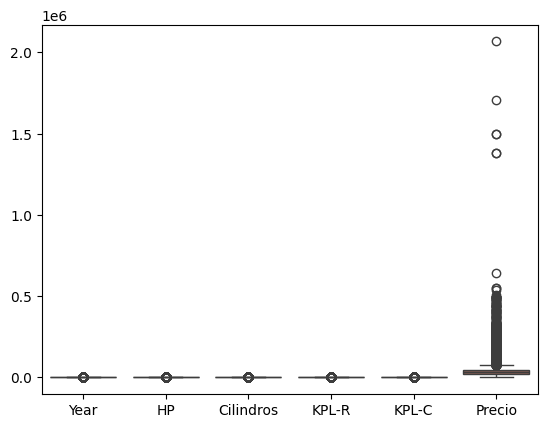

In [30]:
#evaluar todos las columnas del dataframe
sns.boxplot(data=df)

# 9.2 Observar por columnas los valores atípicos (outliers) a través del diagrama de cajas (Bloxplot).

Analicemos por separado para evitar el sesgo de Precio

**9.2.1 Observar la columna precio**

<Axes: xlabel='Precio'>

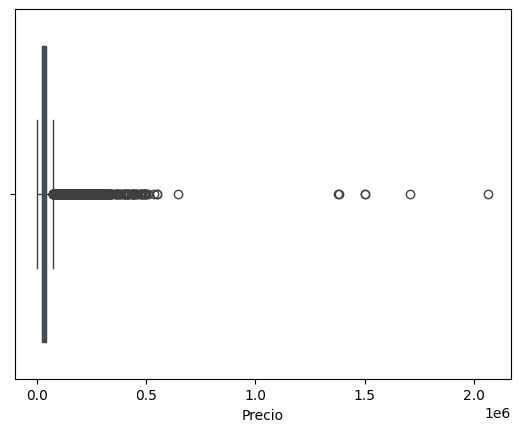

In [31]:
sns.boxplot(x=df['Precio'])

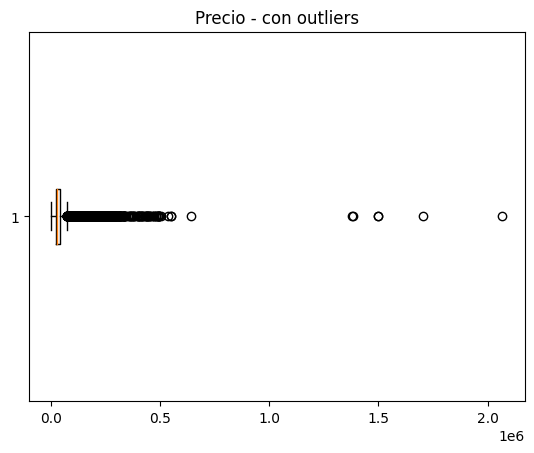

In [55]:
#revisar la misma grafica anterior con otra libreria
plt.title("Precio - con outliers")
plt.boxplot(df["Precio"], vert=False)
plt.show()

**9.2.2 Observar la columna HP**

<Axes: xlabel='HP'>

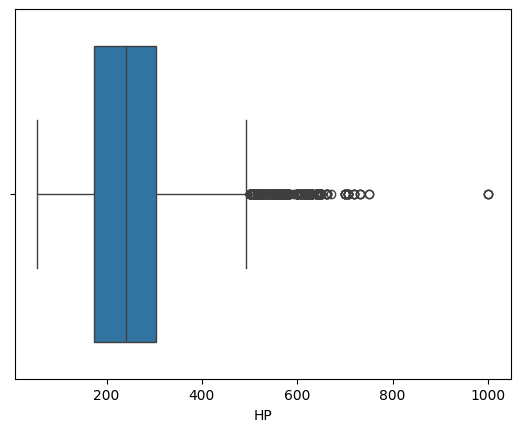

In [32]:
sns.boxplot(x=df['HP'])

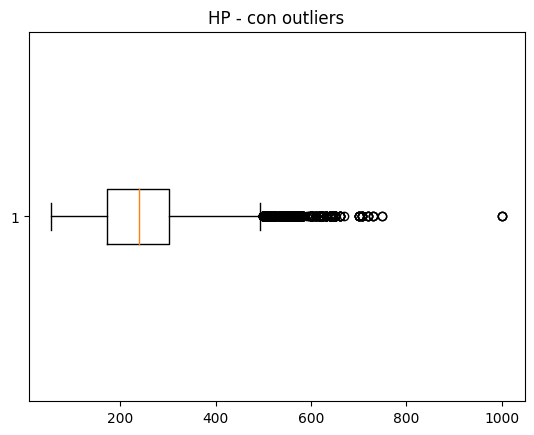

In [33]:
#revisar la misma grafica anterior con otra libreria
plt.title("HP - con outliers")
plt.boxplot(df["HP"], vert=False)
plt.show()

**9.2.3 Observar la columna Cilindros**

<Axes: xlabel='Cilindros'>

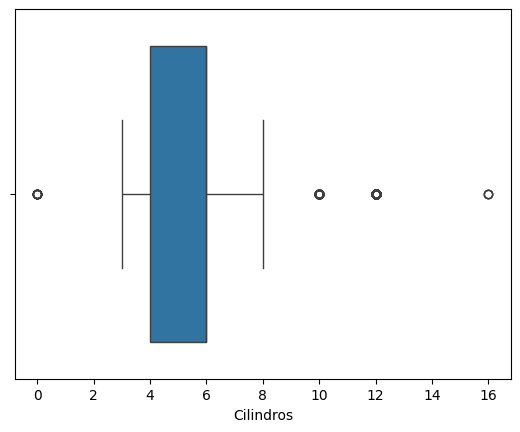

In [34]:
sns.boxplot(x=df['Cilindros'])

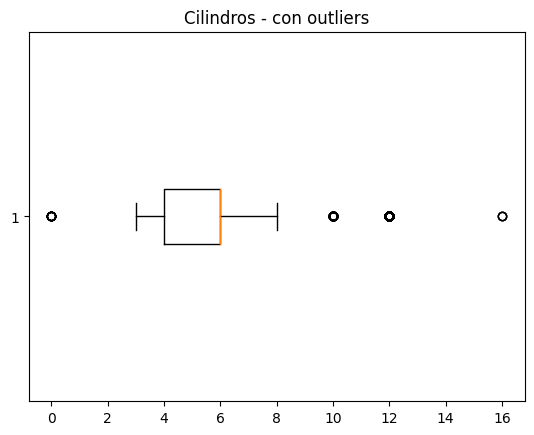

In [35]:
#revisar la misma grafica anterior con otra libreria
plt.title("Cilindros - con outliers")
plt.boxplot(df["Cilindros"], vert=False)
plt.show()

# 9.3 Analicemos la dispersión del precio que como se ve, tiene valores outliers:

<ipython-input-36-768b6b79b070>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Precio'])


,Precio
count,1.082700e+04
mean,4.249325e+04
std,6.229451e+04
min,2.000000e+03
25%,2.197250e+04
50%,3.084500e+04
75%,4.330000e+04
max,2.065902e+06


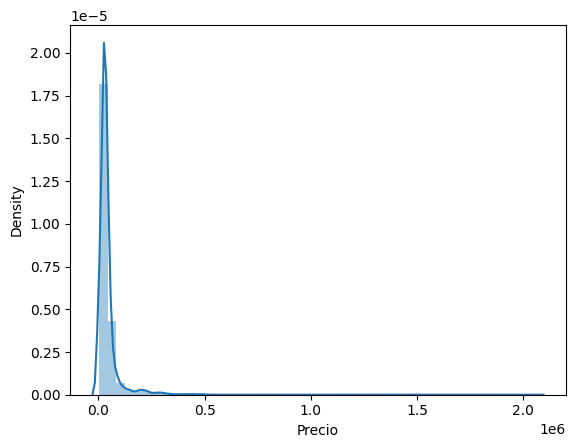

In [36]:
sns.distplot(df['Precio'])
df['Precio'].describe()

Se observa que Precio tiene una larga cola hacia la derecha.

Analicemos los deciles y algunos percentiles para entender esos valores anómalos. Para esto, usaremos el método quantile para calcular los percentiles.

Los cuartiles, que dividen a la distribución en cuatro partes (corresponden a los cuantiles 0,25; 0,50 y 0,75);
Los quintiles, que dividen a la distribución en cinco partes (corresponden a los cuantiles 0,20; 0,40; 0,60 y 0,80);
Los deciles, que dividen a la distribución en diez partes;
Los percentiles, que dividen a la distribución en cien partes.
En el método Quantile: 0, 0.5 y 1 equivalen a valores mínimo, mediana y máximo.

,Precio
0.00,2000.00
0.10,3455.80
0.20,19796.00
0.30,23800.00
0.40,27095.00
0.50,30845.00
0.60,34888.00
0.70,39995.00
0.80,47658.00
0.90,67208.00


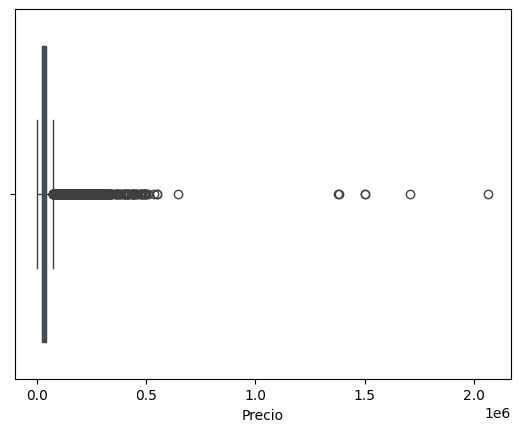

In [ ]:
sns.boxplot(x=df['Precio'])
df['Precio'].quantile([0, .1, .2, .3, .4, .5, .6, .7, .8, .9, .97, .98, .99, 1])

In [ ]:
# podriamos considerar analizar el recorte de los outliers... por ejemplo, recortando entre 200 y el cuartil del 90% (67208 como vimos en la celda anterior)
#es solo sugerencia para analizar

In [ ]:
#--------------------------------------------------------------------------------

Revisemos un método del rango intercuantil para eliminar outliers

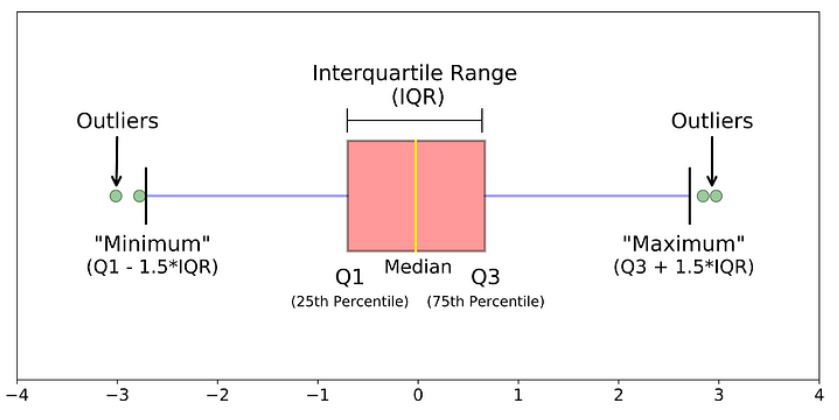

Obtener los datos del diagrama de caja

In [38]:
Q1= df["Precio"].quantile(0.25)
print("Primer Cuartil", Q1)
Q3= df["Precio"].quantile(0.75)
print("Tercer Cuartil", Q3)
IQR= Q3-Q1
print("Rango intercuartil", IQR)

Mediana = df["Precio"].median()
print("Mediana",Mediana)

valor_minimo=  df["Precio"].min()
print("valor_minimo",valor_minimo)

valor_maximo=  df["Precio"].max()
print("valor_maximo",valor_maximo)

Primer Cuartil 21972.5
Tercer Cuartil 43300.0
Rango intercuartil 21327.5
Mediana 30845.0
valor_minimo 2000
valor_maximo 2065902


In [39]:
BI_calculado = (Q1 - 1.5*IQR)
print("BI_calculado ", BI_calculado)
BS_calculado = (Q3+ 1.5*IQR)
print("BS_calculado ", BS_calculado)

BI_calculado  -10018.75
BS_calculado  75291.25


In [41]:
# Tabla Or
#   V or V --> F
#   V or F --> V
#   F or V --> V
#   F or F --> V
#evaluar y obtener outliers con respuesta V

ubicacion_outliers = ((df["Precio"] < BI_calculado) | (df["Precio"] > BS_calculado))

In [42]:
print("ubicacion_outliers", ubicacion_outliers)

ubicacion_outliers 0        False
1        False
2        False
3        False
4        False
         ...  
11909    False
11910    False
11911    False
11912    False
11913    False
Name: Precio, Length: 10827, dtype: bool


In [43]:
outliers = df[ubicacion_outliers]
print(outliers)

           Make Model  Year     HP  Cilindros       Transmision  \
294     Ferrari   360  2002  400.0        8.0            MANUAL   
295     Ferrari   360  2002  400.0        8.0            MANUAL   
296     Ferrari   360  2002  400.0        8.0  AUTOMATED_MANUAL   
297     Ferrari   360  2002  400.0        8.0  AUTOMATED_MANUAL   
298     Ferrari   360  2003  400.0        8.0            MANUAL   
...         ...   ...   ...    ...        ...               ...   
11736  Cadillac   XLR  2008  320.0        8.0         AUTOMATIC   
11737  Cadillac   XLR  2009  320.0        8.0         AUTOMATIC   
11903       BMW    Z8  2001  394.0        8.0            MANUAL   
11904       BMW    Z8  2002  394.0        8.0            MANUAL   
11905       BMW    Z8  2003  394.0        8.0            MANUAL   

               Tracción     KPL-R     KPL-C  Precio  
294    rear wheel drive  2.711211  4.251440  160829  
295    rear wheel drive  2.711211  4.251440  140615  
296    rear wheel drive  2.711211

In [44]:
outliers_ordenado = outliers.sort_values("Precio")
outliers_ordenado["Precio"]

,Precio
8915,75300
11531,75300
6485,75465
6483,75465
6492,75465
...,...
6351,1382750
11363,1500000
8486,1500000
11364,1705769


Ahora, obtenemos los registros que no son outliers

In [46]:
ubicacion_no_outliers = ((df["Precio"] >= BI_calculado) & (df["Precio"] <= BS_calculado))

In [47]:
print("ubicacion_no_outliers", ubicacion_no_outliers)

ubicacion_no_outliers 0        True
1        True
2        True
3        True
4        True
         ... 
11909    True
11910    True
11911    True
11912    True
11913    True
Name: Precio, Length: 10827, dtype: bool


In [48]:
sin_outliers = df[ubicacion_no_outliers]
print(sin_outliers)

          Make       Model  Year     HP  Cilindros Transmision  \
0          BMW  1 Series M  2011  335.0        6.0      MANUAL   
1          BMW    1 Series  2011  300.0        6.0      MANUAL   
2          BMW    1 Series  2011  300.0        6.0      MANUAL   
3          BMW    1 Series  2011  230.0        6.0      MANUAL   
4          BMW    1 Series  2011  230.0        6.0      MANUAL   
...        ...         ...   ...    ...        ...         ...   
11909    Acura         ZDX  2012  300.0        6.0   AUTOMATIC   
11910    Acura         ZDX  2012  300.0        6.0   AUTOMATIC   
11911    Acura         ZDX  2012  300.0        6.0   AUTOMATIC   
11912    Acura         ZDX  2013  300.0        6.0   AUTOMATIC   
11913  Lincoln      Zephyr  2006  221.0        6.0   AUTOMATIC   

                Tracción     KPL-R     KPL-C  Precio  
0       rear wheel drive  4.699433  8.077736   46135  
1       rear wheel drive  5.060928  8.077736   40650  
2       rear wheel drive  5.060928  8.5028

In [49]:
sin_outliers_ordenado = sin_outliers.sort_values("Precio")
sin_outliers_ordenado["Precio"]

,Precio
912,2000
1287,2000
3813,2000
3815,2000
3819,2000
...,...
2092,75000
10021,75010
3027,75195
2391,75200


Resultado de eliminar outliers se muestra a continuación

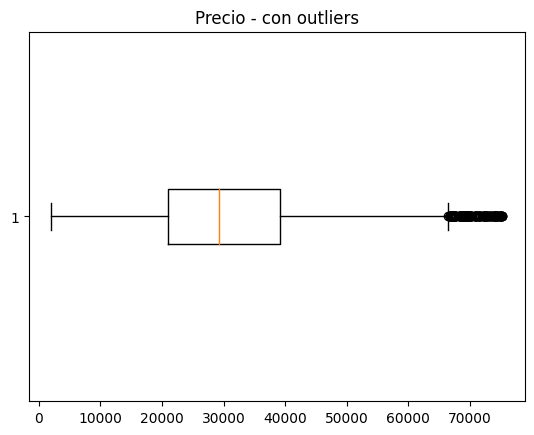

In [51]:
plt.title("Precio - con outliers")
plt.boxplot(sin_outliers_ordenado["Precio"], vert=False)
plt.show()

# **10. Gráficas**

# 10.1 Histograma

El histograma es una gráfica que representa la cantidad de ocurrencias de una variable en un intervalo determinado. En este dataset tenemos principalmente 10 diferentes marcas de fabricantes, pero es importante saber saber quién tiene la mayor cantidad de autos. Este histograma es una solución trivial para saber cuántos autos fabrica cada compañía.

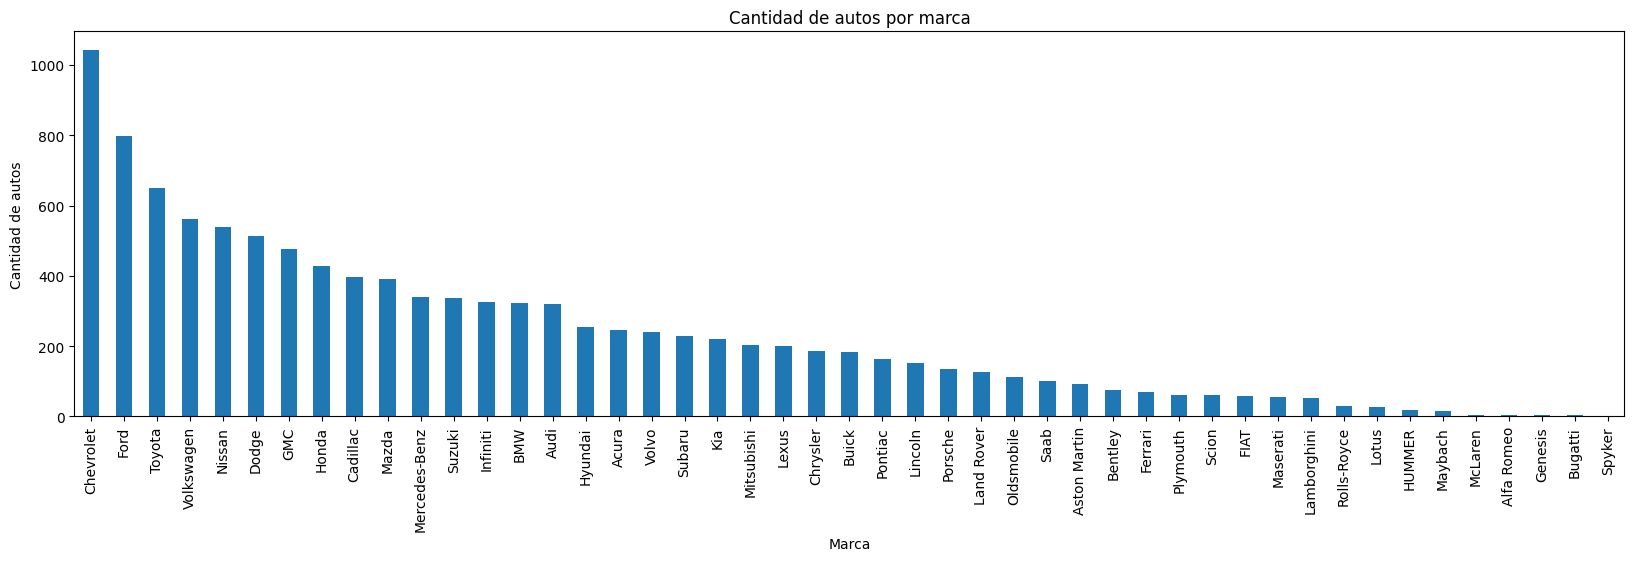

In [52]:
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html
df["Make"].value_counts().plot(kind='bar', figsize=(20,5))
plt.title("Cantidad de autos por marca")
plt.ylabel('Cantidad de autos')
plt.xlabel('Marca');

# 10.2 Mapas de Calor

Los mapas de calor son gráficas que sirven para determinar variables dependientes. Una de las mejores maneras para encontrar estas relaciones es utilizando un mapa de calor. En el siguiente mapa de calor encontramos que el precio es una característica dependiente del tamaño del motor, de la potencia y de la cantidad de cilindros.

En el mapa de calor podemos representar la correlación entre  las relaciones entre variables cuantitativas o variables categóricas. Es una medida de cómo se relacionan las cosas. La tabla siguiente nos muestra cómo podemos interpretar los coeficientes de correlación.

Como dijimos anteriormente, seaborn es una biblioteca increíble que nos ayuda a visualizar nuestras variables de manera fácil y clara. El método heatmap() nos muestra la relación entre variables numéricas.


Existen diferentes métodos para calcular el coeficiente de correlación;

*   Pearson
*   Kendall
*   Lancero






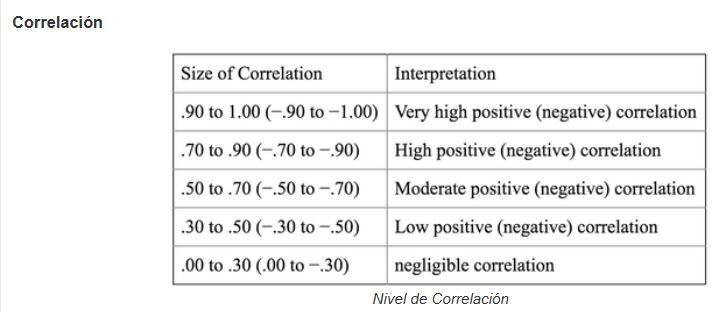

In [ ]:
#ma=df[["Year","HP", "Cilindros",	"KPL-R","KPL-C","Precio"]]

In [53]:
df_new = df[['Year','HP', 'Cilindros',	'KPL-R','KPL-C','Precio']]


,Year,HP,Cilindros,KPL-R,KPL-C,Precio
Year,1.000000,0.284885,-0.105876,0.344945,0.311695,0.465656
HP,0.284885,1.000000,0.767437,-0.506422,-0.602524,0.831801
Cilindros,-0.105876,0.767437,1.000000,-0.758158,-0.834417,0.507563
KPL-R,0.344945,-0.506422,-0.758158,1.000000,0.948430,-0.234728
KPL-C,0.311695,-0.602524,-0.834417,0.948430,1.000000,-0.312924
Precio,0.465656,0.831801,0.507563,-0.234728,-0.312924,1.000000


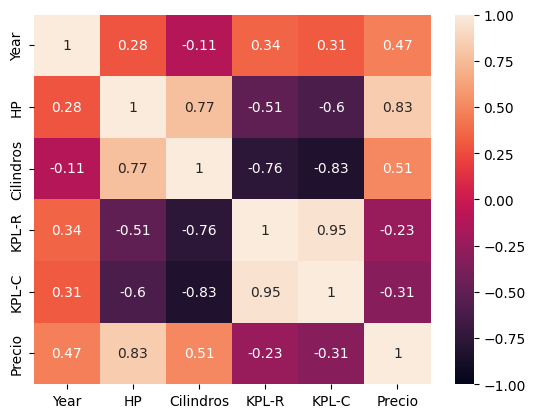

In [54]:
correlaciones= df_new.corr(method="spearman")
#heatmap = sns.heatmap(datos.corr(), vmin=-1, vmax=1, annot=True)
sns.heatmap(correlaciones, vmin=-1, vmax=1, annot=True)
correlaciones

# 10.3 Dispersión

Usamos este tipo de gráficas para encontrar correlación entre 2 variables. Acá graficamos precio en función de la potencia.
We generally use scatter plots to find the correlation between two variables. Here the scatter plots are plotted between Horsepower and Price and we can see the plot below. With the plot given below, we can easily draw a trend line. These features provide a good scattering of points.

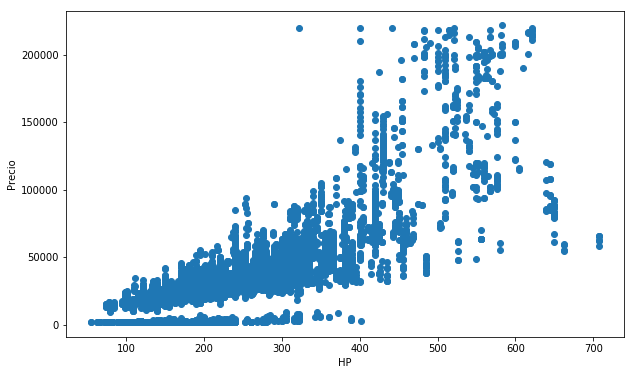

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(df['HP'], df['Precio'])
ax.set_xlabel('HP')
ax.set_ylabel('Precio')
plt.show()

Con la gráfica anterior vemos que se puede trazar claramente una línea de tendencia.